<a href="https://colab.research.google.com/github/Imesh-Isuranga/ME-422-Group-B1/blob/main/Vibration/E20140.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Activity 1: Derivation oF 2-DOF Model that will Capture the First Two Dominant Modes of Small Amplitude Vibration of the System**

Consider following schematic diagram of the experimental setup with given notations.
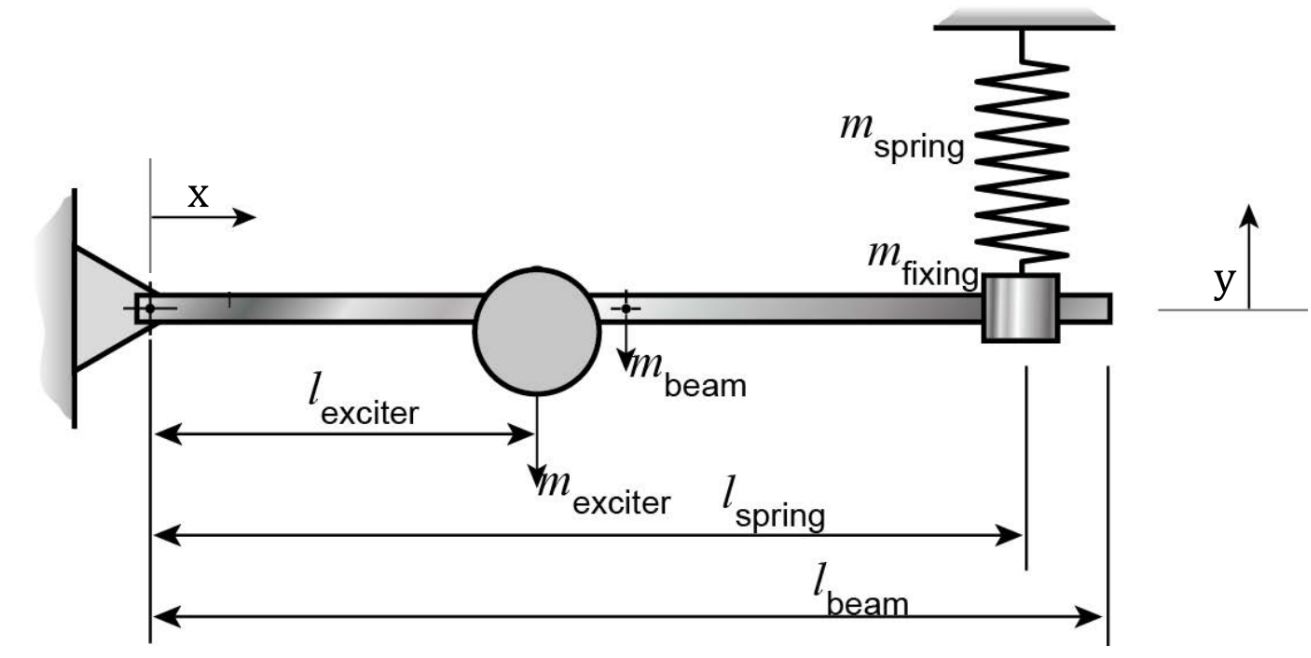
Figure 1: Schematic without damper

For small amplitude transverse vibrations of a slender beam, the system can be sufficiently accurately described by following PDE using Euler-Bernoulli beam theory as a continous system.

$$
{\rho A}{{\partial^2 y} \over {\partial t^2}} + c{{\partial y} \over {\partial t}}+EI{{\partial^4 y} \over {\partial x^4}}+P {{\partial^2 y} \over {\partial x^2}}=f(t,x)
$$

where $P$ is the axial compressive force, $\rho$ is the density of the material of the beam, and $E$ is the modulus of elasticity, $I$ is the cross sectional moment of inertia, $A$ is the cross sectional area of the uniform beam, $c$ is the distributed viscous damping per unit length along the beam, and $f(t,x)$ is the external tranverse load per unit length.

Since $P = 0$ for this case, the above PDE can be reduced to:

$$
{\rho A}{{\partial^2 y} \over {\partial t^2}} + c{{\partial y} \over {\partial t}}+EI{{\partial^4 y} \over {\partial x^4}}=f(t,x)
$$

The solutions of the above PDE that satisfy the boundary conditions of a beam with one end free and the base (rotational) elastically restrained with a spring.

\begin{align*}y(0,t)&=0,\:\:\:\:\:\:\: {\partial^3 y \over \partial x^3}(l_{beam},t)=0,\\ EI{\partial^2 y \over \partial x^2}(0,t)-k_{\theta}{\partial y \over \partial x}(0,t)&=0,\:\:\:\:\:\:\: {\partial^2 y \over \partial x^2}(l_{beam},t)=0,\end{align*}

where $k_{\theta} = k_{spring}l_{spring}^2$ is the rotational stiffness

**Free Vibration Analysis for Mode Shapes:**

Let $\mathfrak{F}$ be the infintie dimensional vector space of four times differentiable functions defined on the interval $[0,L]$. Then $H: \mathfrak{F}\mapsto \mathfrak{F}$ defined by

\begin{align}H&=\frac{EI} {\rho A}{{\partial^4 } \over {\partial x^4}}
\end{align}

is a linear operator on $\mathfrak{F}$ and the equations of motion take the form

\begin{align*}
{{\partial^2 y} \over {\partial t^2}} + C{{\partial y} \over {\partial t}}+Hy&=q(t,x)
\end{align*}

where $c = C \rho A$ and $f(t) = \rho A q(t)$

$H$ maps a transverse deflection shape to the acceleration caused purely by beam bending, subject to the beam’s boundary conditions. Let $H$ have distinct positive eignevalues $\{\omega_k^2\}_{k=1}^\infty$ with corrsponding eigenfunctions $\{\psi_k\}_{k=1}^\infty$ i.e. mode shapes.

Then, the eigenvalue problem can be defined as:

\begin{align*}
H \psi_k(x) &= \omega_k^2 \psi(x)
\end{align*}

Substituting $H$, we get:

\begin{align*}
\frac{EI}{\rho A} \frac{\partial^4 \psi_k(x)}{\partial x^4} &= \omega_k^2 \psi_k(x) \\
\frac{\partial^4 \psi_k(x)}{\partial x^4} &= \frac{\rho A \, \omega_k^2}{EI} \psi_k(x)  \\
\frac{\partial^4 \psi_k(x)}{\partial x^4} &= \beta_k^4 \psi_k(x)
\end{align*}

where $\beta_k^4 = \frac{\rho A \, \omega_k^2}{EI}$

The general solution of the fourth-order differential equation $(1)$ is

\begin{align*}
\psi_k(x) = A_k \cosh(\beta_k x) + B_k \sinh(\beta_k x) + C_k \cos(\beta_k x) + D_k \sin(\beta_k x)
\end{align*}

where $A_k$, $B_k$, $C_k$, $D_k$ are constants determined from boundary conditions.

Boundary condition at base-end:

$$
\psi_k(0) = 0 \quad \Rightarrow \quad A_k + C_k = 0
$$

<br>

\begin{align*}
\psi_k'(0) &= \beta_k(B_k+D_k) \\
\psi_k''(0) &= \beta_k^2(A_k-C_k)
\end{align*}

Noting that $C_k = -A_k$, substitute $\psi_k'(0)$ and $\psi_k''(0)$ to,

\begin{align*}
EI \beta_k^2(A_k-C_k) - k_{\theta}\beta_k(B_k+D_k) &= 0 \\
2EI \beta_k^2A_k - k_{\theta}\beta_k(B_k+D_k) &= 0
\end{align*}

Boundary conditions at free-end:

\begin{align*}
\psi_k''(l_{beam}) = 0 & \Rightarrow
& A_k(\cosh(\beta_k l_{beam}) + \cos(\beta_k l_{beam})) + B_k\sinh(\beta_k l_{beam}) - D_k\sin(\beta_k l_{beam})  = 0 \\
\psi_k'''(l_{beam}) = 0 & \Rightarrow
& A_k(\sinh(\beta_k l_{beam}) - \sin(\beta_k l_{beam})) + B_k\cosh(\beta_k l_{beam}) - D_k \cos(\beta_k l_{beam}) = 0
\end{align*}

<br>

The above three equations form a linear homogeneous system.

$$
\mathbf{H}(\beta_k)\begin{bmatrix} A_k \\ B_k \\ D_k \end{bmatrix} = \mathbf{0}
$$

where $\mathbf{H}(\beta_k) \in \mathbb{M_{3x3}}$

For non-trivial solutions, $\text{det}\,\mathbf{H}(\beta_k) = 0$. Let us solve the determinent numerically to find $\beta_k$ for $k \in \mathbb{N}$ and the linear homogeneous system to find $A_k$, $B_k$ and $D_k$

In [ ]:
import numpy as np
from numpy.linalg import det
from scipy.linalg import svd
from scipy.linalg import eigh
from scipy.optimize import brentq
from scipy.integrate import odeint
from scipy.integrate import quad
import matplotlib.pyplot as plt

# ========= Determinent of the Characteristic Matrix =========
def char_det(beta, l_beam, EI, k_theta):

    bL = beta * l_beam

    H = np.array([
        [2*EI*beta**2,      -k_theta*beta,  -k_theta*beta],
        [np.cosh(bL)+np.cos(bL), np.sinh(bL), -np.sin(bL)],
        [np.sinh(bL)-np.sin(bL), np.cosh(bL), -np.cos(bL)]
    ])

    return det(H)

def find_betas(l_beam, EI, k_theta, n_roots=2, beta_max=50):
    betas = []
    beta_vals = np.linspace(1e-4, beta_max, 5000)

    f_vals = [char_det(b, l_beam, EI, k_theta) for b in beta_vals]

    for i in range(len(beta_vals)-1):
        if f_vals[i]*f_vals[i+1] < 0:
            root = brentq(
                char_det,
                beta_vals[i],
                beta_vals[i+1],
                args=(l_beam, EI, k_theta)
            )
            betas.append(root)

            if len(betas) >= n_roots:
                break

    return np.array(betas)

# ============ Solving for A,B,C,D Coefficients ===========
def mode_shape_coefficients(beta, l_beam, EI, k_theta):
    bL = beta * l_beam

    H = np.array([
        [2*EI*beta**2,      -k_theta*beta,  -k_theta*beta],
        [np.cosh(bL)+np.cos(bL), np.sinh(bL), -np.sin(bL)],
        [np.sinh(bL)-np.sin(bL), np.cosh(bL), -np.cos(bL)]
    ])

    # SVD -> right singular vector corresponding to smallest singular value
    U, S, Vh = svd(H)
    v = Vh[-1, :].copy()   # v ~ [A, B, D] up to sign/scale

    A, B, D = v
    C = -A
    return A, B, C, D

Then, the eigenvalues of $H$ are given by,

$$
\{\omega_k^2\}_{k=1}^\infty = \left\{\frac{EI}{\rho A}{\beta_k}^4\right\}_{k=1}^\infty
$$

and the eigenfunctions/mode shapes of $H$ are given by,

$$
\{\psi_k\}_{k=1}^\infty = \left\{A_k \cosh(\beta_k x) + B_k \sinh(\beta_k x) + C_k \cos(\beta_k x) + D_k \sin(\beta_k x)\right\}_{k=1}^\infty
$$

$A_k$, $B_k$, $C_k$ and $D_k$ to be found using numerical methods programmed in above functions.

**Forced Vibration Response using Modal Expansion:**

In the event the oscillator is turned on, a forced vibration takes place due to oscillating force $Q$.

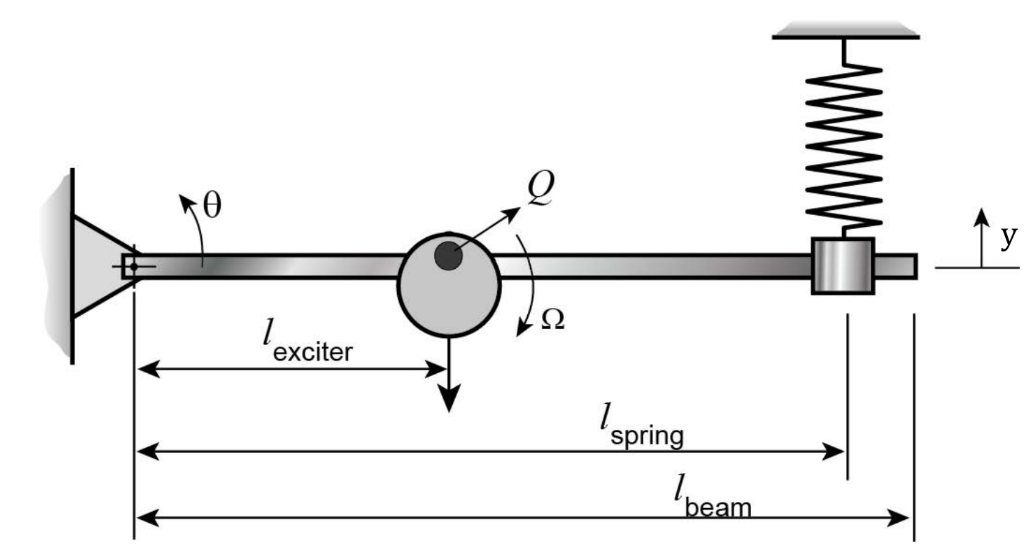